# 2 — An entity resolution report

Notebook 01 loaded 153,094 records from eight California business data sources.
Senzing has decided which of them describe the same real-world company or person.
This notebook asks what it decided, and whether we should believe it.

By the end we will be able to answer:

- **How many entities** are there, and how much did 153,094 records compress?
- **Which sources overlap**, and by how much?
- **How big are the entities** — and are any suspiciously big?
- **What drove the matches** — which features did Senzing actually rely on?
- **What did it nearly match** but leave apart?
- **Can we trust it?** — with actual records shown as evidence, not just totals.

> Nothing here is a guess about Senzing's internals. Every number comes from
> Senzing's own export, and the structure of the report follows Senzing's published
> evaluation framework.

---
## 1. Connect

In [1]:
import grpc
from senzing_grpc import SzAbstractFactoryGrpc

channel = grpc.insecure_channel("senzing:8261")
senzing = SzAbstractFactoryGrpc(channel)
engine = senzing.create_engine()

Before anything else — if there are redo records still waiting, the numbers below are
not final. Go back and finish section 12 of notebook 01.

In [2]:
print(f"{engine.count_redo_records():,} redo records outstanding (should be 0)")

0 redo records outstanding (should be 0)


---
## 2. Where the numbers come from

Senzing can stream out every resolved entity it holds. Each row of that export is one
entity: its id, its name, the records that resolved into it, and the other entities it
is related to.

We make **one pass** over that stream and collect everything we need into plain Python
structures. Every report after this is a few lines over what we collected — no second
scan, no database queries.

A note on what we are *not* doing: Senzing also supports a "data mart" of
pre-aggregated report tables, which is the right answer at production scale. Those
tables do not exist out of the box — they are built and maintained by a separate
replication pipeline. For 145,000 entities a single export pass takes about a minute,
so we read the source of truth directly.

In [3]:
import json
import time
from collections import Counter, defaultdict

entity_records = {}                  # entity id -> [(data source, record id), ...]
entity_names = {}                    # entity id -> name Senzing chose
match_principles = Counter()         # (rule, match key) -> how many records
relationships = {}                   # (lower id, higher id) -> kind of relationship
relationship_keys = {}               # (lower id, higher id) -> what nearly matched

Two details in the loop below are worth knowing, because getting either wrong quietly
corrupts the numbers.

**Relationships appear twice.** Each one is listed on *both* entities it connects, so
we key them on the id pair sorted low-to-high and let the second sighting overwrite
the first. Counting them as they arrive would double every total.

**The first record into an entity has no match key.** A match key records *why this
record joined the ones already there*, so the founding record has nothing to explain.
Those blanks are skipped — they are not a failure to match.

In [4]:
started = time.time()

for line in engine.export_json_entity_report_iterator():
    entity = json.loads(line)
    resolved = entity["RESOLVED_ENTITY"]
    entity_id = resolved["ENTITY_ID"]

    entity_names[entity_id] = resolved["ENTITY_NAME"]
    entity_records[entity_id] = [
        (record["DATA_SOURCE"], record["RECORD_ID"]) for record in resolved["RECORDS"]
    ]

    for record in resolved["RECORDS"]:
        if record["MATCH_KEY"]:
            match_principles[(record["ERRULE_CODE"], record["MATCH_KEY"])] += 1

    for related in entity.get("RELATED_ENTITIES", []):
        pair = (min(entity_id, related["ENTITY_ID"]), max(entity_id, related["ENTITY_ID"]))
        relationships[pair] = related["MATCH_LEVEL_CODE"]
        relationship_keys[pair] = related["MATCH_KEY"]

print(f"read {len(entity_records):,} entities in {time.time() - started:.0f}s")

read 145,448 entities in 58s


---
## 3. The headline

Two numbers and their ratio. **Compression** is the share of records that turned out
to be duplicates of something else — 0% would mean nothing matched anything.

In [5]:
total_entities = len(entity_records)
total_records = sum(len(members) for members in entity_records.values())
compression = 1 - total_entities / total_records

print(f"records in   : {total_records:,}")
print(f"entities out : {total_entities:,}")
print(f"compression  : {compression:.1%}")

records in   : 153,094
entities out : 145,448
compression  : 5.0%


---
## 4. Setting up the tables and charts

The rest of this notebook is tables and bar charts, so we set up both once here.

Every chart is a single series — a count per category — so every bar gets the **same**
colour. Colouring bars darker-where-bigger would encode the same fact twice and add
nothing. The value is printed at the end of each bar because a static chart has no
tooltip to fall back on, and each chart is paired with the table it came from.

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

SERIES_COLOUR = "#2a78d6"
GRID_COLOUR = "#eceae5"
LABEL_COLOUR = "#52514e"


def bar_chart(labels, values, title, xlabel):
    """Horizontal bars, one colour, value printed at the end of each bar."""
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(labels) + 1.4))
    positions = range(len(labels))

    ax.barh(positions, values, color=SERIES_COLOUR, height=0.62)
    ax.set_yticks(list(positions), labels)
    ax.invert_yaxis()
    ax.set_title(title, loc="left", pad=14, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=9, color=LABEL_COLOUR)

    for value, position in zip(values, positions):
        ax.text(value, position, f"  {value:,}", va="center", fontsize=9, color=LABEL_COLOUR)

    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOUR)
    ax.tick_params(length=0, labelsize=9)
    ax.xaxis.grid(True, color=GRID_COLOUR, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.margins(x=0.14)
    fig.tight_layout()
    plt.show()

---
## 5. Each source on its own

How much did each file deduplicate against everything else? A **singleton** is a
record that ended up alone in its entity — it matched nothing, anywhere.

In [7]:
source_records = Counter()
source_entities = defaultdict(set)
source_singletons = Counter()

for entity_id, members in entity_records.items():
    for data_source, _ in members:
        source_records[data_source] += 1
        source_entities[data_source].add(entity_id)
        if len(members) == 1:
            source_singletons[data_source] += 1

In [8]:
per_source = pd.DataFrame(
    [
        {
            "data source": name,
            "records": source_records[name],
            "entities": len(source_entities[name]),
            "compression": 1 - len(source_entities[name]) / source_records[name],
            "singletons": source_singletons[name],
            "singleton rate": source_singletons[name] / source_records[name],
        }
        for name in sorted(source_records)
    ]
).sort_values("records", ascending=False)

per_source.style.format({"records": "{:,}", "entities": "{:,}", "singletons": "{:,}",
                         "compression": "{:.1%}", "singleton rate": "{:.1%}"}).hide(axis="index")

data source,records,entities,compression,singletons,singleton rate
CSLB_PERSONNEL,"78,096","78,065",0.0%,"78,034",99.9%
CSLB_CONTRACTORS,"48,130","47,643",1.0%,"46,376",96.4%
CA_SOS_FILINGS,"7,801","7,730",0.9%,"7,651",98.1%
CA_SOS_AGENTS,"7,421","4,958",33.2%,"3,681",49.6%
CA_SOS_PRINCIPALS,"5,701","3,313",41.9%,"1,535",26.9%
BURLINGAME_LICENSES,"4,781","4,761",0.4%,"3,886",81.3%
CA_ABC_RETAIL,"1,009",887,12.1%,770,76.3%
CA_ABC_NONRETAIL,155,83,46.5%,40,25.8%


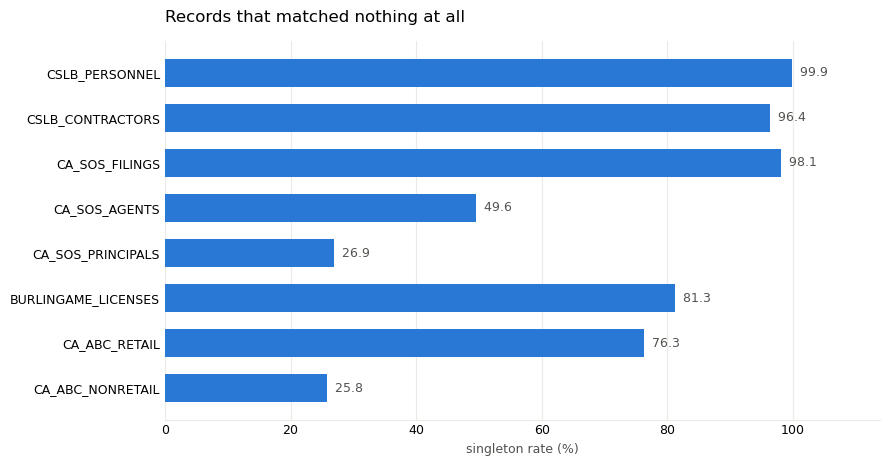

In [9]:
bar_chart(
    per_source["data source"].tolist(),
    (per_source["singleton rate"] * 100).round(1).tolist(),
    "Records that matched nothing at all",
    "singleton rate (%)",
)

Read this against what you know about the files. A high singleton rate is not
automatically bad — a file of genuinely distinct businesses *should* be mostly
singletons. It is only a problem when you expected overlap and did not get it.

The one to look at hardest is `CSLB_PERSONNEL`. Those records carry a name and
nothing else — no address, no date of birth, no identifier — because the source file
has nothing else in it. Name alone is weak evidence, so most of those people stay
separate. That is Senzing being careful, not Senzing failing.

---
## 6. Where the sources overlap

This is the question the whole exercise exists to answer: how many entities contain
records from **more than one** agency? Those are the businesses and people that four
separate agencies each knew about, without any of them sharing a key.

In [10]:
cross_source = Counter()
entities_spanning_sources = 0

for entity_id, members in entity_records.items():
    sources = {data_source for data_source, _ in members}
    if len(sources) > 1:
        entities_spanning_sources += 1
        for first in sorted(sources):
            for second in sorted(sources):
                if first < second:
                    cross_source[(first, second)] += 1

print(f"{entities_spanning_sources:,} entities span more than one data source")

1,992 entities span more than one data source


In [11]:
overlap = pd.DataFrame(
    [
        {
            "source A": a,
            "source B": b,
            "shared entities": count,
            "% of A": count / len(source_entities[a]),
            "% of B": count / len(source_entities[b]),
        }
        for (a, b), count in cross_source.most_common()
    ]
)

overlap.style.format({"shared entities": "{:,}", "% of A": "{:.1%}",
                      "% of B": "{:.1%}"}).hide(axis="index")

source A,source B,shared entities,% of A,% of B
CA_SOS_AGENTS,CA_SOS_PRINCIPALS,"1,089",22.0%,32.9%
BURLINGAME_LICENSES,CSLB_CONTRACTORS,852,17.9%,1.8%
CA_SOS_FILINGS,CA_SOS_PRINCIPALS,36,0.5%,1.1%
BURLINGAME_LICENSES,CA_ABC_RETAIL,11,0.2%,1.2%
CA_SOS_FILINGS,CSLB_CONTRACTORS,2,0.0%,0.0%
CA_SOS_AGENTS,CSLB_CONTRACTORS,1,0.0%,0.0%
CA_ABC_NONRETAIL,CSLB_CONTRACTORS,1,1.2%,0.0%


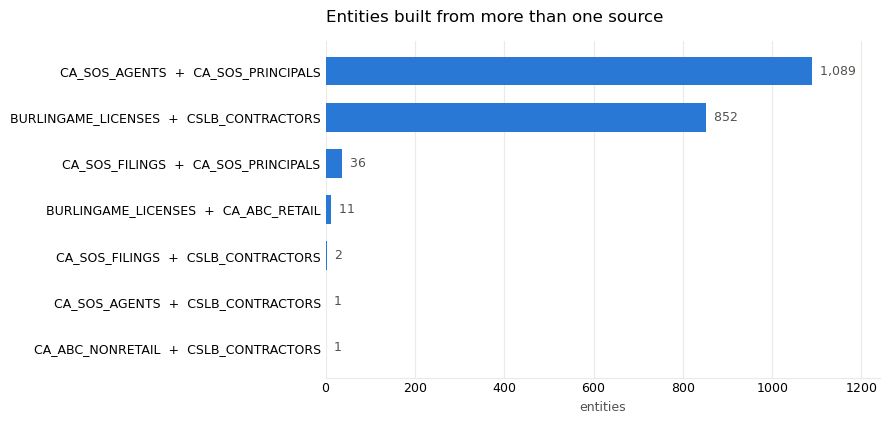

In [12]:
bar_chart(
    [f"{a}  +  {b}" for a, b in [tuple(r) for r in overlap[["source A", "source B"]].values]],
    overlap["shared entities"].tolist(),
    "Entities built from more than one source",
    "entities",
)

The percentages matter more than the raw counts. A pair sharing 80%+ of its entities
would suggest the two files are near-copies of each other. A pair sharing almost
nothing suggests either that they genuinely cover different populations, or that they
have no features in common strong enough to match on.

---
## 7. How big are the entities?

Entity size distribution is the single most useful quality signal. Too many
singletons and Senzing is being too cautious; unexpectedly huge entities and it is
being too eager — different real businesses jammed together by a common name.

In [13]:
def size_bucket(size):
    if size == 1:
        return "1  (matched nothing)"
    if size == 2:
        return "2"
    if size <= 5:
        return "3-5"
    if size <= 10:
        return "6-10"
    if size <= 50:
        return "11-50"
    return "51+  (worth a look)"


BUCKET_ORDER = ["1  (matched nothing)", "2", "3-5", "6-10", "11-50", "51+  (worth a look)"]

sizes = Counter(size_bucket(len(members)) for members in entity_records.values())

In [14]:
size_table = pd.DataFrame(
    [
        {
            "records per entity": bucket,
            "entities": sizes.get(bucket, 0),
            "share of entities": sizes.get(bucket, 0) / total_entities,
        }
        for bucket in BUCKET_ORDER
    ]
)

size_table.style.format({"entities": "{:,}", "share of entities": "{:.1%}"}).hide(axis="index")

records per entity,entities,share of entities
1 (matched nothing),"141,973",97.6%
2,"2,391",1.6%
3-5,"1,022",0.7%
6-10,32,0.0%
11-50,22,0.0%
51+ (worth a look),8,0.0%


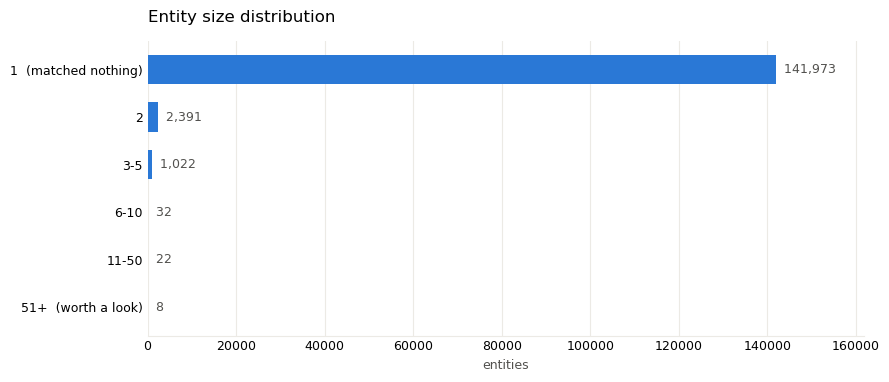

In [15]:
bar_chart(
    BUCKET_ORDER,
    [sizes.get(bucket, 0) for bucket in BUCKET_ORDER],
    "Entity size distribution",
    "entities",
)

One bar swamps the rest, and that lopsidedness is the finding rather than a fault in
the chart — the great majority of records matched nothing at all. Read the printed
values and the table for the small buckets. (A log scale would make them visible but
would also disguise just how dominant the singletons are, which is the one thing this
chart most needs to say.)

That shape is what you would expect here. Five of the eight files are registries of
distinct businesses, so most rows genuinely have no counterpart. The interesting
entities are the few thousand in the `2` and `3-5` buckets, and the handful at the
bottom worth checking by eye.

---
## 8. What actually drove the matches?

Every record that joined an existing entity carries a **match key** saying which
features agreed — `+NAME+ADDRESS` means the name and the address both lined up. The
`ERRULE_CODE` beside it is the rule Senzing applied.

This is the most direct check on our mapping work in notebook 01. If we mapped
addresses and phone numbers but no match key ever mentions them, then something we
thought we mapped is not reaching the matcher.

In [16]:
principles = pd.DataFrame(
    [
        {"rule": rule, "match key": key, "records": count,
         "share": count / sum(match_principles.values())}
        for (rule, key), count in match_principles.most_common(15)
    ]
)

principles.style.format({"records": "{:,}", "share": "{:.1%}"}).hide(axis="index")

rule,match key,records,share
CNAME_CFF_CEXCL,+NAME+ADDRESS,"5,826",76.2%
,+EXACTLY_SAME,"1,279",16.7%
MFF_LNAME_CEXCL,+NAME+ADDRESS+PHONE,258,3.4%
CNAME_CFF_CEXCL,+NAME+ADDRESS+REGISTRATION_DATE,68,0.9%
CNAME_CFF,+NAME+PHONE,65,0.9%
MFF_LNAME_CEXCL,+ADDRESS+PHONE+LIKELY_NAME,53,0.7%
CNAME_CFF,+NAME+ADDRESS,45,0.6%
MFF_CNAME,+NAME+ADDRESS+PHONE,33,0.4%
SNAME_SSTAB,+NAME+REGISTRATION_DATE,17,0.2%


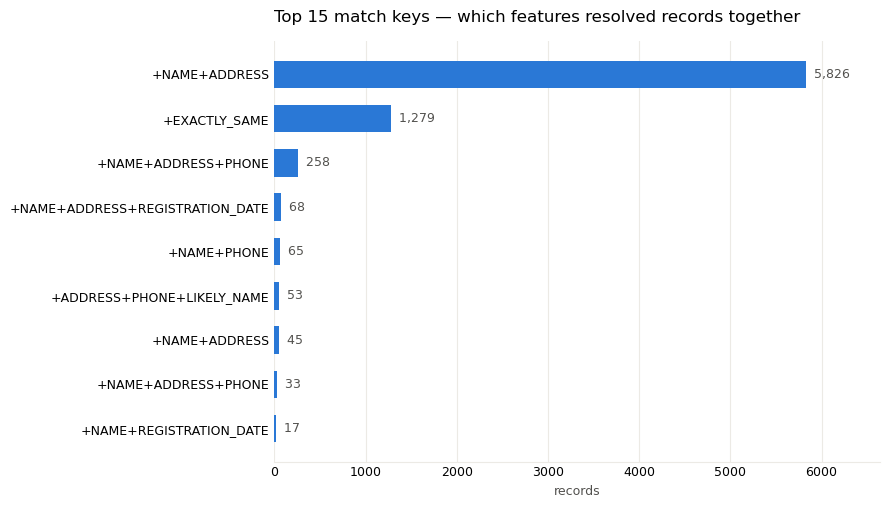

In [17]:
bar_chart(
    principles["match key"].tolist(),
    principles["records"].tolist(),
    "Top 15 match keys — which features resolved records together",
    "records",
)

Check the list against what notebook 01 mapped: names, addresses, one phone column,
and the ABC licence number. Anything mapped that never appears here is worth
investigating — either the column is emptier than it looked, or it is not reaching
the matcher at all.

---
## 9. What Senzing *nearly* matched

Not every comparison ends in a merge. Senzing also records relationships between
entities it kept apart:

- **`POSSIBLY_SAME`** — strong evidence, not quite enough to merge. This is the review
  queue, and it is where under-matching hides.
- **`POSSIBLY_RELATED`** — a weaker association, probably different things.
- **`DISCLOSED`** — not a guess at all. These are the `PRINCIPAL_OF` and `AGENT_OF`
  links *we* supplied in notebook 01, which is why there are so many.

In [18]:
kinds = Counter(relationships.values())

pd.DataFrame(
    [{"relationship": kind, "pairs": count} for kind, count in kinds.most_common()]
).style.format({"pairs": "{:,}"}).hide(axis="index")

relationship,pairs
DISCLOSED,"87,080"
POSSIBLY_SAME,"17,152"
POSSIBLY_RELATED,"5,931"


The `POSSIBLY_SAME` pile is the interesting one. If a single match key dominates it,
that is a strong hint that one more mapped feature would tip those pairs over into
real matches.

In [19]:
possibly_same = [pair for pair, kind in relationships.items() if kind == "POSSIBLY_SAME"]
near_miss_keys = Counter(relationship_keys[pair] for pair in possibly_same)

pd.DataFrame(
    [{"match key": key, "pairs": count} for key, count in near_miss_keys.most_common(10)]
).style.format({"pairs": "{:,}"}).hide(axis="index")

match key,pairs
+NAME,"16,909"
+NAME+ADDRESS-REGISTRATION_DATE,115
+NAME+REGISTRATION_DATE,74
+NAME-REGISTRATION_DATE,18
+LIKELY_NAME+ADDRESS+REGISTRATION_DATE,15
+NAME+REGISTRATION_DATE-ADDRESS,11
+NAME+ADDRESS+PHONE (Ambiguous),4
+NAME+ADDRESS+REGISTRATION_DATE (Ambiguous),2
+NAME+ADDRESS-RECORD_TYPE,2
+LIKELY_NAME+ADDRESS+PHONE (Ambiguous),2


---
## 10. Evidence: look at the actual records

Everything above is aggregates, and aggregates hide mistakes. An entity of 40 records
looks the same in a bar chart whether it is one real business or forty different ones
wrongly merged.

So we look. This helper pulls up an entity and prints the **real data** from every
record in it.

In [20]:
def show_entity(entity_id, limit=8):
    """Print an entity and the actual mapped data of the records inside it."""
    members = entity_records[entity_id]
    print(f"entity {entity_id}: {entity_names[entity_id]}  ({len(members):,} records)")

    for data_source, record_id in members[:limit]:
        record = json.loads(engine.get_record(data_source, record_id))
        details = []
        for item in record["JSON_DATA"]["FEATURES"]:
            for key, value in item.items():
                if key.startswith(("NAME_", "ADDR_")) and not key.endswith("_TYPE"):
                    details.append(value)
        print(f"   {data_source:<20} {record_id[:26]:<26} {' | '.join(details)[:90]}")

    if len(members) > limit:
        print(f"   ... and {len(members) - limit:,} more")

### The biggest entities

These are the over-matching candidates. Read the records: is this one business that
appears many times, or several businesses that share a name?

In [21]:
biggest = sorted(entity_records, key=lambda eid: len(entity_records[eid]), reverse=True)[:3]

pd.DataFrame(
    [{"entity": eid, "name": entity_names[eid], "records": len(entity_records[eid])}
     for eid in biggest]
).style.hide(axis="index")

entity,name,records
7824,NORTHWEST REGISTERED AGENT INC,585
7841,UNITED STATES CORPORATION AGENTS INC,305
7953,ZENBUSINESS INC,205


In [ ]:
show_entity(biggest[0])

This is exactly why the framework insists on looking. The largest entity in the
database is enormous — and it is **correct**. It is a commercial registered-agent
firm, the kind of company businesses pay to be their agent for service of process, so
it is legitimately named on hundreds of separate filings. Same company name, same
Sacramento address, hundreds of times over.

The bar chart cannot tell you that. Only the records can.

Compare the two shapes when you look at a large entity:

- **Correct**: one name and one address repeated, as here. A real thing that appears
  many times.
- **Over-matched**: several *different* addresses or noticeably different names sharing
  one generic name. That is several businesses forced together.

### A cross-source match

The payoff case: one entity holding records from two different agencies.

In [ ]:
cross_source_entities = [
    eid for eid, members in entity_records.items()
    if len({data_source for data_source, _ in members}) > 1
]

show_entity(cross_source_entities[0])

### A near miss

And one pair Senzing decided *not* to merge. `why_entities` explains what agreed and
what did not — this is how you tell a correct rejection from a missed match.

In [ ]:
left, right = possibly_same[0]

print(f"{entity_names[left]}  ({left})")
print(f"{entity_names[right]}  ({right})")
print("matched on:", relationship_keys[(left, right)])

In [ ]:
why = json.loads(engine.why_entities(left, right))

why["WHY_RESULTS"][0]["MATCH_INFO"]

---
## What this report tells us

Work back through it in order:

1. **Compression** — how much of the 153,094 was duplication.
2. **Per source** — which files deduplicated and which stayed distinct, with the
   singleton rate saying why.
3. **Overlap** — how many entities more than one agency knew about. This is the
   number that justifies doing entity resolution at all; a plain join on these files
   would have found none of them.
4. **Size distribution** — the shape of the result, and whether anything is
   suspiciously large.
5. **Match keys** — which of the features we mapped are actually doing the work.
6. **Possible matches** — the near misses, and the best guide to what mapping one
   more column would buy.
7. **The records themselves** — because the four points above are only trustworthy if
   the underlying data holds up when you look at it.

**One caveat worth stating plainly.** None of this measures accuracy in absolute
terms. Precision and recall need a truth set — a list of the right answers — and we
do not have one for this data. What we have are proxies: size distribution, overlap
rates, near misses, and our own reading of sampled records. Proxies reveal problems
well; they cannot prove their absence.

Where to go next:

- `engine.how_entity_by_entity_id(...)` — the step-by-step merge sequence for one
  entity, showing which record joined at each stage and why.
- `engine.find_network_by_record_id(...)` — follow the `PRINCIPAL_OF` and `AGENT_OF`
  relationships outward into a graph.
- `engine.search_by_attributes(...)` — look up an entity by name and address, the way
  an application would.